# Lab 5: Group Recommender Systems

## Section 1: Data Preparation and Exploration

### The MovieLens Dataset

[MovieLens](https://grouplens.org/datasets/movielens/) is one of the most popular (publicly) available datasets for benchmarking. In this notebook, we will work with the [1M](https://grouplens.org/datasets/movielens/1m/) version, which contains 1,000,209 anonymous ratings of approximately 3,900 movies made by 6,040 MovieLens users who joined MovieLens in 2000.

Let's load this data with pandas

In [44]:
from urllib.request import urlretrieve
import zipfile, os

In [45]:
# If file exists, skip the download
data_file_path = "movielens/Movielens1M/"
data_file_name = data_file_path + "movielens_1m.zip"

# If directory does not exist, create
if not os.path.exists(data_file_path):
    os.makedirs(data_file_path)

if not os.path.exists(data_file_name):
    urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", data_file_name)

In [46]:
# unzip and read the *.dat files
dataFile = zipfile.ZipFile(data_file_path + "movielens_1m.zip")

ratings_path = dataFile.extract("ml-1m/ratings.dat",path=data_file_path)# Fill in
users_path = dataFile.extract("ml-1m/users.dat",path=data_file_path)# Fill in
movies_path = dataFile.extract("ml-1m/movies.dat",path=data_file_path)# Fill in

### Let's take a look at the data

Let us focus on the ratings of users for items

In [47]:
import pandas as pd

In [48]:
ratings_df = pd.read_table(ratings_path, sep="::", header=None, names=["user","item","rating","timestamp"]) # Fill in

display(ratings_df.head(10))

,user,item,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


In [49]:
# Check number of ratings per user
rating_per_user_df = ratings_df.groupby(['user']).count().sort_values(by="rating", ascending=False)
display(rating_per_user_df)

,item,rating,timestamp
user,,,
4169,2314,2314,2314
1680,1850,1850,1850
4277,1743,1743,1743
1941,1595,1595,1595
1181,1521,1521,1521
...,...,...,...
5725,20,20,20
3407,20,20,20
1664,20,20,20


In [50]:
# Check number of ratings per item
rating_per_item_df = ratings_df.groupby(["user"]).count().sort_values(by="rating", ascending=False)# Fill in
display(rating_per_item_df)

,item,rating,timestamp
user,,,
4169,2314,2314,2314
1680,1850,1850,1850
4277,1743,1743,1743
1941,1595,1595,1595
1181,1521,1521,1521
...,...,...,...
5725,20,20,20
3407,20,20,20
1664,20,20,20


(Optional) Homework: try to change min_ratings_per_item and observe the new results

In [51]:
# select items with the desidered number of ratings
min_ratings_per_item = 100

selected_items = list(rating_per_item_df.loc[rating_per_item_df['rating'] >= min_ratings_per_item].reset_index()['item'])

In [52]:
# select ratings for the selected items
display(ratings_df.shape)

selected_ratings_df = ratings_df.loc[ratings_df["item"].isin(selected_items)]# Fill in
display(selected_ratings_df.shape)

(1000209, 4)

(168382, 4)

In [53]:
# Check again number of ratings per user
rating_per_user_df = selected_ratings_df.groupby(["user"]).count().sort_values(by="rating", ascending=False)# Fill in
display(rating_per_user_df)

,item,rating,timestamp
user,,,
4169,379,379,379
1680,344,344,344
4277,287,287,287
3391,255,255,255
1181,253,253,253
...,...,...,...
4629,1,1,1
5314,1,1,1
1438,1,1,1


In [54]:
# Save dataset
selected_ratings_df[['user','item','rating']].to_csv("./ratings.csv", index=False)

In [55]:
import numpy as np

df = selected_ratings_df.groupby('item').agg({"rating": [np.sum, np.prod,np.min,np.max]})
display(df)
display(df['rating']['sum'].reset_index())

rating                          
        sum              prod min max
item                                 
100     392                 0   1   5
101     979                 0   1   5
102     109     3131031158784   1   4
103     106  5572562780160000   1   5
104    2405                 0   1   5
...     ...               ...  ..  ..
1518   1211                 0   1   5
1595    113     1114512556032   1   4
1743     43           1200000   1   5
1850     37            276480   1   5
2314    326                 0   1   5

[628 rows x 4 columns]

,item,sum
0,100,392
1,101,979
2,102,109
3,103,106
4,104,2405
...,...,...
623,1518,1211
624,1595,113
625,1743,43
626,1850,37


## Section 2: Synthetic Groups Generation

Question: Do you remember how many types of group that we have for group recommender systems?

In [56]:
import pandas as pd

ratings_df = pd.read_csv("./ratings.csv")
display(ratings_df.head(10))

,user,item,rating
0,1,661,3
1,1,914,3
2,1,720,3
3,1,527,5
4,1,150,5
5,1,260,4
6,1,531,4
7,1,608,4
8,2,434,2
9,2,292,3


### Similarity evaluation

Evaluation of the similarity between all the pairs of users in the dataset.

In [57]:
# computing similarity between each pair of users

import numpy as np

user_matrix = ratings_df.pivot_table(columns="item",index="user",values="rating")# Fill in

user_id_set = set(ratings_df['user'])
user_id_indexes = user_matrix.index.values
user_matrix = user_matrix.fillna(0)
numpy_array = user_matrix.to_numpy()
sim_matrix = np.corrcoef(numpy_array)

In [58]:
display(sim_matrix)

array([[ 1.    , -0.0212,  0.1585, ..., -0.0076,  0.1937,  0.2541],
       [-0.0212,  1.    ,  0.1765, ...,  0.2708, -0.0348,  0.1127],
       [ 0.1585,  0.1765,  1.    , ..., -0.0067,  0.1186,  0.0436],
       ...,
       [-0.0076,  0.2708, -0.0067, ...,  1.    , -0.0126,  0.1521],
       [ 0.1937, -0.0348,  0.1186, ..., -0.0126,  1.    ,  0.2157],
       [ 0.2541,  0.1127,  0.0436, ...,  0.1521,  0.2157,  1.    ]])

### Visualization of the similarity distribution

Text(0.5, 0, "Pearson's Correlation Coeficient")

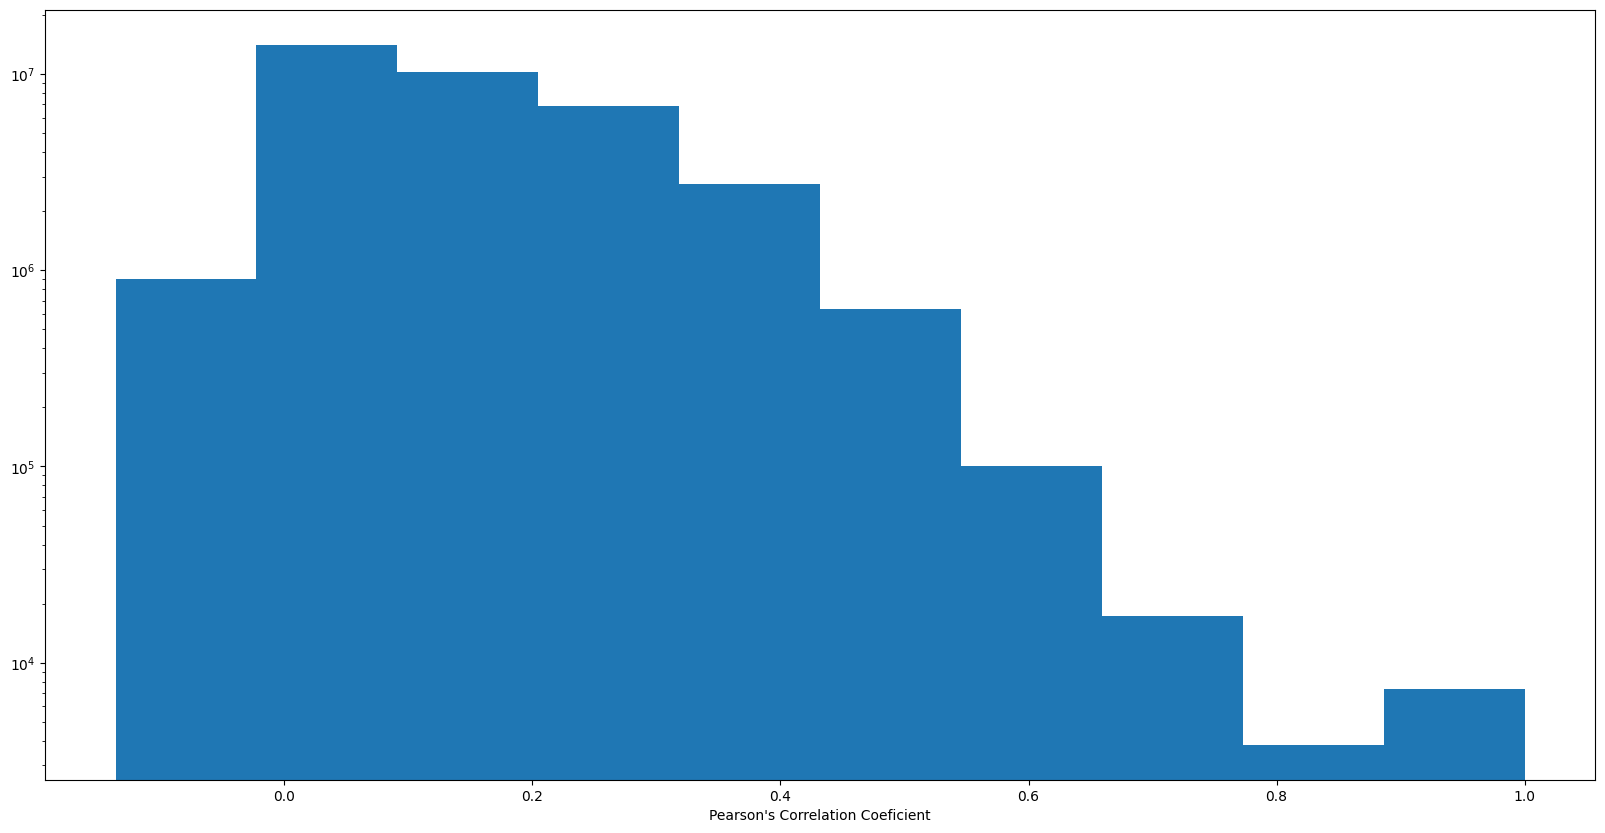

In [59]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(sim_matrix.flatten())
plt.yscale("log")
plt.xlabel("Pearson's Correlation Coeficient")

In [60]:
import numpy as np
import random

In [61]:
def compute_average_similarity(group, user_id_indexes, sim_matrix):
    similarities = list()

    for user_1 in group:
        user_1_index = user_id_indexes.tolist().index(user_1)
        for user_2 in group:
            user_2_index = user_id_indexes.tolist().index(user_2)
            if user_1 != user_2:
                similarities.append(sim_matrix[user_1_index][user_2_index])# Fill in

    return np.mean(similarities)

In [62]:
def select_user_for_sim_group(group, sim_matrix, user_id_indexes, sim_threshold=0.4):
    ids_to_select_from = set()

    for member in group:
        member_index = user_id_indexes.tolist().index(member)
        indexes = np.where(sim_matrix[member_index] >= sim_threshold)[0].tolist()
        user_ids = [user_id_indexes[index] for index in indexes]
        ids_to_select_from = ids_to_select_from.union(set(user_ids))

    candidate_ids = ids_to_select_from.difference(set(group))

    if len(candidate_ids) == 0:
        return None
    else:
        # Convert candidate_ids to a list before using random.sample
        selection = random.sample(list(candidate_ids), 1)
        return selection[0]

In [63]:
def generateSimilarGroups(user_id_indexes, user_id_set, similarity_matrix, group_sizes_to_create, group_number_to_create, sim_threshold):
    groups_list = list()

    for group_size in group_sizes_to_create:
        groups_size_list = list()
        while (len(groups_size_list) < group_number_to_create):
            # Convert user_id_set to a list before using random.sample
            group = random.sample(list(user_id_set), 1)
            while len(group) < group_size:
                new_member = select_user_for_sim_group(group,
                                                       similarity_matrix,
                                                       user_id_indexes,
                                                       sim_threshold=sim_threshold)# Fill in
                if new_member is None:
                    break
                group.append(new_member)
            if len(group) == group_size:
                groups_size_list.append(
                    {
                        "group_size": group_size,
                        "group_similarity": 'similar',
                        "group_members": group,
                        "avg_similarity": compute_average_similarity(group, user_id_indexes, similarity_matrix)# Fill in
                    }
                )
        groups_list.extend(groups_size_list)
        print(len(groups_list))
    return groups_list

In [64]:
def generateRandomGroups(user_id_indexes, user_id_set, similarity_matrix, group_sizes_to_create, group_number_to_create):
    groups_list = list()
    for group_size in group_sizes_to_create:
      for i in range(group_number_to_create):
        # Convert user_id_set to a list before using random.sample
        group = random.sample(list(user_id_set), group_size)
        groups_list.append(
            {
              "group_size": group_size,
              "group_similarity": 'random',
              "group_members": group,
              "avg_similarity": compute_average_similarity(group, user_id_indexes, similarity_matrix)
            }
        )
      print(len(groups_list))
    return groups_list

## Section 3: Now we will generate groups

In [65]:
group_number = 20
group_sizes_to_create = [2, 5]
similar_threshold = 0.5

similar_list = generateSimilarGroups(user_id_indexes, user_id_set, sim_matrix, group_sizes_to_create, group_number,similar_threshold)
random_list = generateRandomGroups(user_id_indexes, user_id_set, sim_matrix, group_sizes_to_create, group_number)# Fill in

group_list = similar_list + random_list

20
40
20
40


In [66]:
group_dict = dict()
for group_id, group in zip(range(len(group_list)), group_list):
    group_dict[group_id] = group

display(group_dict)

{0: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [2623, 4120],
  'avg_similarity': 0.5099685313097658},
 1: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [2786, 985],
  'avg_similarity': 0.5364484709876418},
 2: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [4913, 3862],
  'avg_similarity': 0.5812498478875736},
 3: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [2927, 2836],
  'avg_similarity': 0.5021078490410096},
 4: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [735, 3033],
  'avg_similarity': 0.533637860779828},
 5: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [2034, 1493],
  'avg_similarity': 0.612319569246051},
 6: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [3684, 1497],
  'avg_similarity': 0.5410567491240403},
 7: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [434, 4196],
  'avg_similar

In [67]:
# simple similarity viewer per group
np.set_printoptions(precision=4, suppress=True)

idx = 75
member_index = [user_id_indexes.tolist().index(member) for member in group_dict[idx]["group_members"]]# Fill in
s = sim_matrix[member_index]
s[:,member_index]

array([[ 1.    ,  0.0259,  0.2619,  0.1535, -0.0105],
       [ 0.0259,  1.    , -0.0194,  0.3599, -0.0134],
       [ 0.2619, -0.0194,  1.    ,  0.0637, -0.0066],
       [ 0.1535,  0.3599,  0.0637,  1.    , -0.0076],
       [-0.0105, -0.0134, -0.0066, -0.0076,  1.    ]])

In [68]:
import pickle
pickle.dump(group_dict, open("./group_composition.pkl", "wb"))

We explore group similarity for "similar" and "random"

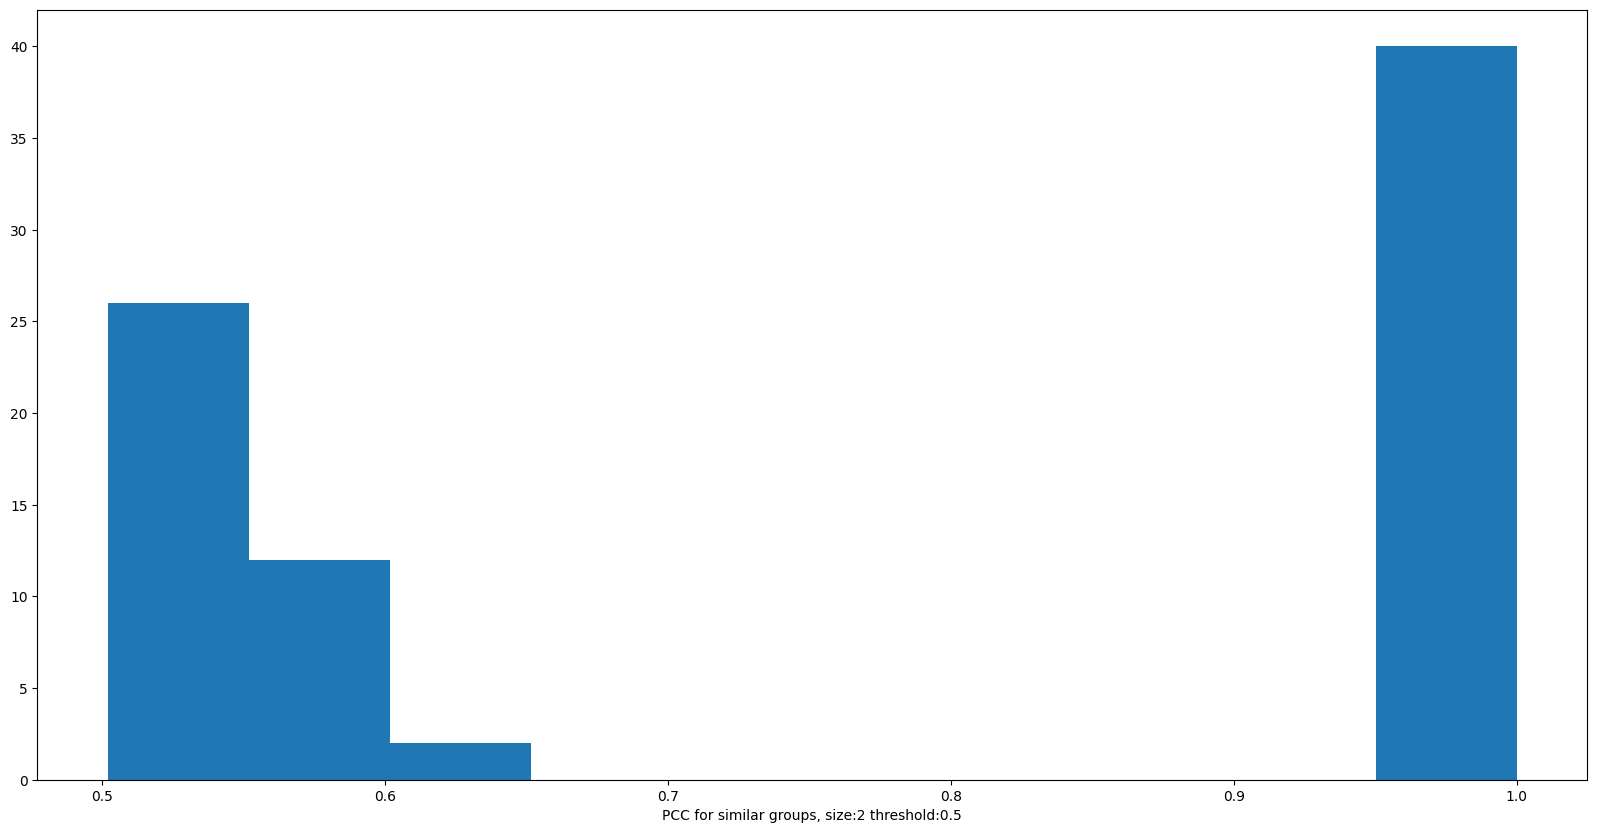

In [69]:
group_similarity = "similar"
group_size = 2

histogram_list = []
for gid in group_dict.keys():
    g = group_dict[gid]
    if g["group_similarity"] == group_similarity and g["group_size"] == group_size:
        member_index = [user_id_indexes.tolist().index(member) for member in g["group_members"]]
        s = sim_matrix[member_index]
        histogram_list.extend(s[:,member_index].flatten().tolist())


plt.hist(histogram_list)
#plt.yscale("log")
plt.xlabel("PCC for "+group_similarity+" groups, size:"+str(group_size)+" threshold:"+str(similar_threshold))
plt.savefig("pcc_"+group_similarity+"_"+str(group_size)+"_"+str(int(similar_threshold*10))+".png", dpi=300)

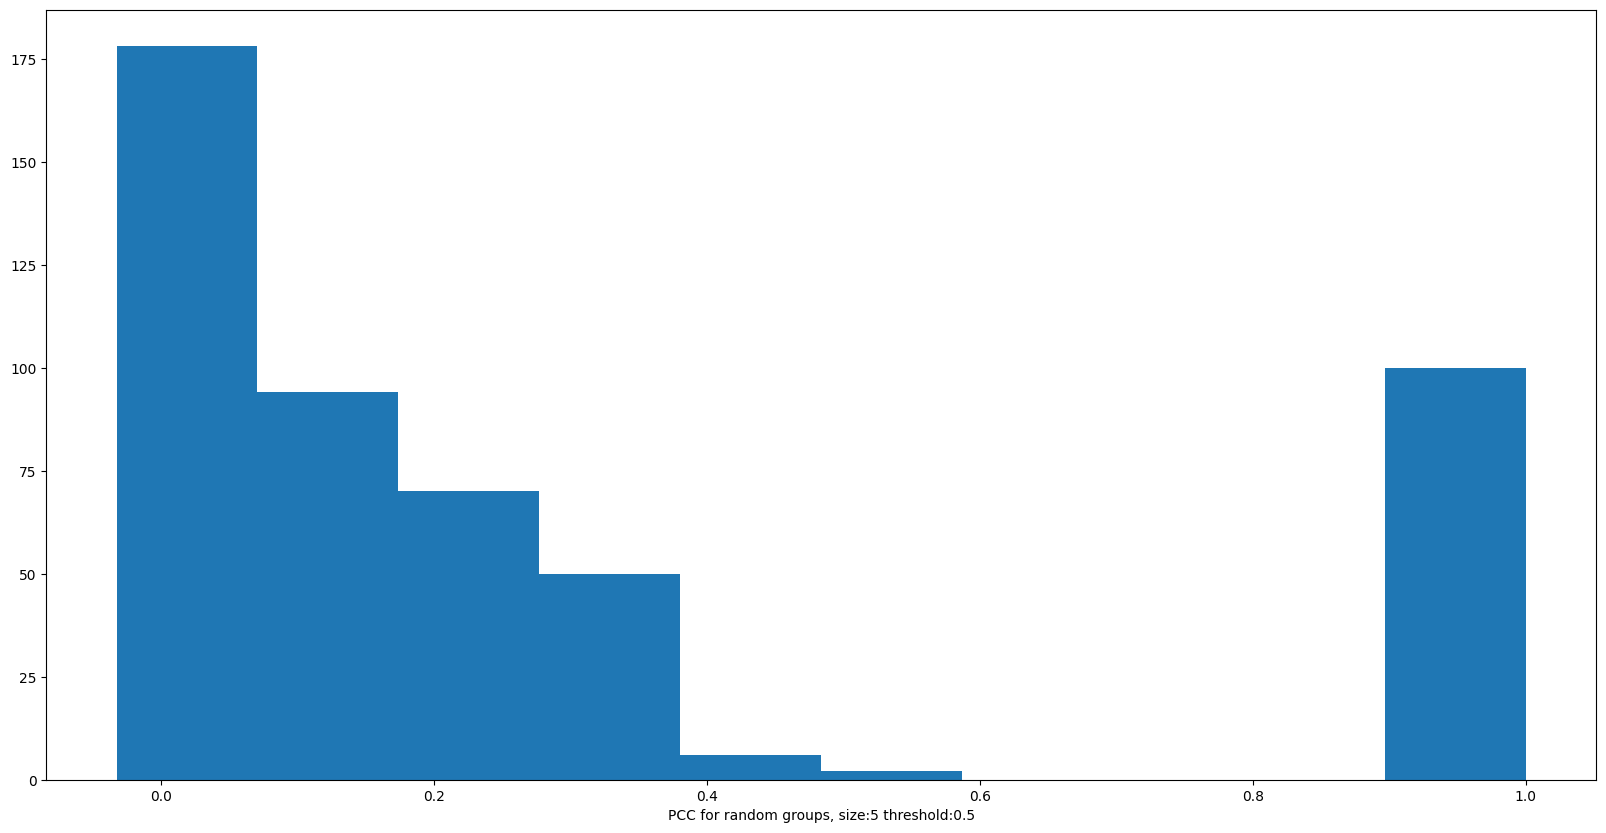

In [70]:
group_similarity = "random"
group_size = 5

histogram_list = []
for gid in group_dict.keys():
    g = group_dict[gid]
    if g["group_similarity"] == group_similarity and g["group_size"] == group_size:
      member_index = [user_id_indexes.tolist().index(member) for member in g["group_members"]]
      s = sim_matrix[member_index]
      histogram_list.extend(s[:, member_index].flatten().tolist())


plt.hist(histogram_list)
#plt.yscale("log")
plt.xlabel("PCC for "+group_similarity+" groups, size:"+str(group_size)+" threshold:"+str(similar_threshold))
plt.savefig("pcc_"+group_similarity+"_"+str(group_size)+"_"+str(int(similar_threshold*10))+".png", dpi=300)

In [71]:
groups_list = list()
for group in group_dict:
    groups_list.append(
        {
            'group_id': group,
            'group_size': group_dict[group]['group_size'],
            'group_similarity': group_dict[group]['group_similarity'],
            'group_members': group_dict[group]['group_members'],
            'avg_similarity': group_dict[group]['avg_similarity']
        }
    )

groups_df = pd.DataFrame.from_records(groups_list)
display(groups_df.head(10))

,group_id,group_size,group_similarity,group_members,avg_similarity
0,0,2,similar,"[2623, 4120]",0.509969
1,1,2,similar,"[2786, 985]",0.536448
2,2,2,similar,"[4913, 3862]",0.581250
3,3,2,similar,"[2927, 2836]",0.502108
4,4,2,similar,"[735, 3033]",0.533638
5,5,2,similar,"[2034, 1493]",0.612320
6,6,2,similar,"[3684, 1497]",0.541057
7,7,2,similar,"[434, 4196]",0.537503
8,8,2,similar,"[4096, 2862]",0.525795
9,9,2,similar,"[2242, 2035]",0.516529


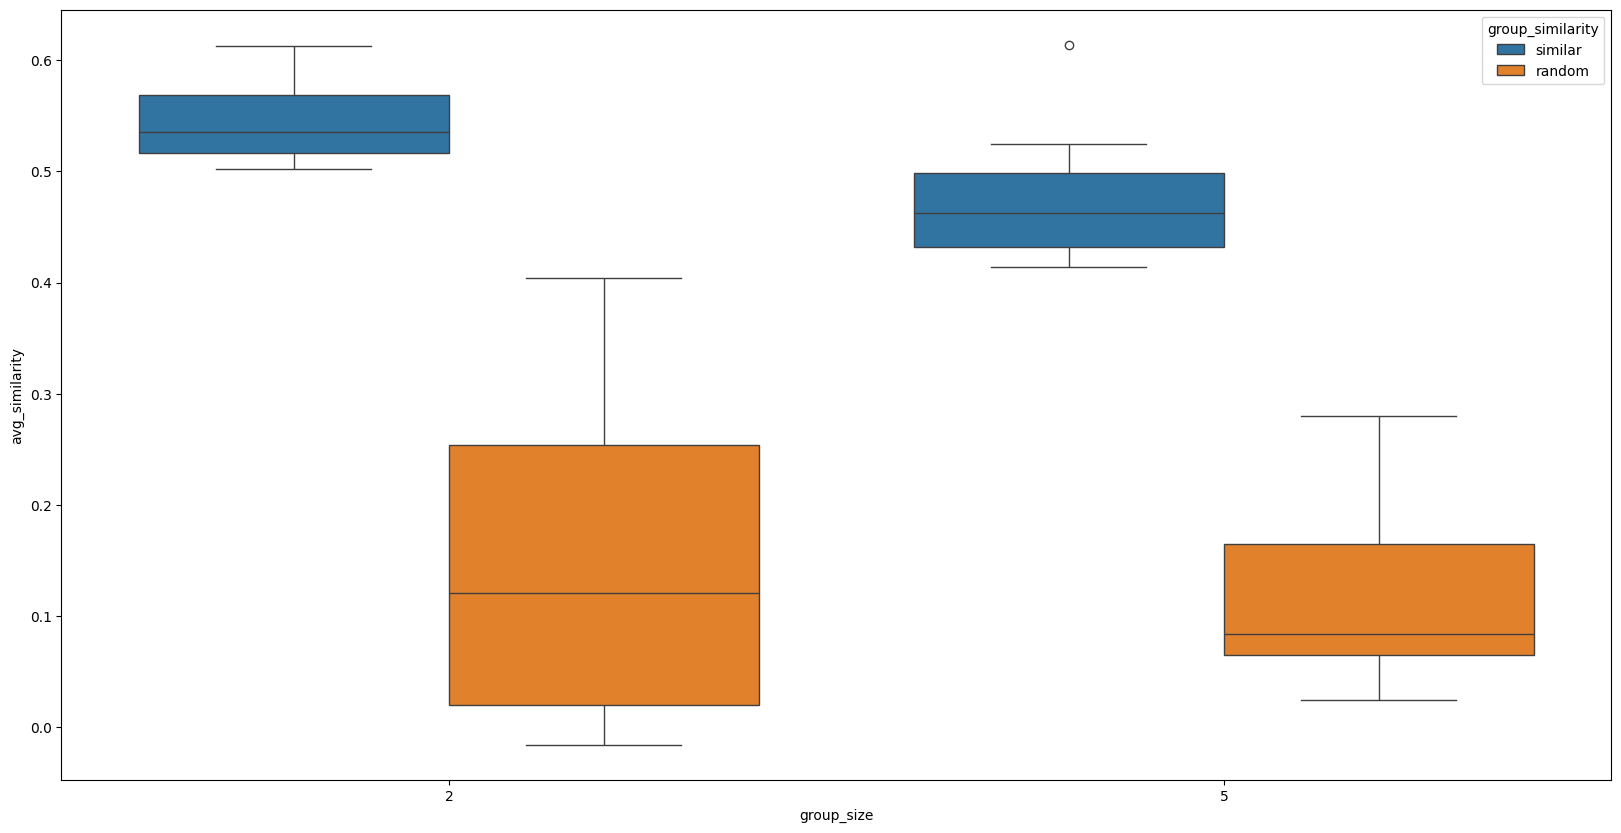

In [72]:
# Comparing groups internal average similarity between the different types and sizes

import seaborn as sns

plt.rcParams["figure.figsize"] = (20,10)
sns.boxplot(x = groups_df['group_size'],
            y = groups_df['avg_similarity'],
            hue = groups_df['group_similarity'])
import matplotlib.pyplot as plt

In [73]:
groups_df.to_csv("./group_composition.csv")

## Section 4: Train group recommendation model

In [74]:
!pip install lenskit

In [75]:
!pip install lenskit==0.14.4

In [76]:
!pip install numpy==1.25

In [77]:
import pandas as pd
import pickle

from lenskit.algorithms import Recommender
from lenskit.algorithms.user_knn import UserUser
from lenskit.algorithms.item_knn import ItemItem
from sklearn.model_selection import train_test_split
from lenskit import batch, topn, util

In [78]:
ratings_df = pd.read_csv("./ratings.csv")
group_composition = pickle.load(open("./group_composition.pkl", "rb"))

len(group_composition)

80

In [79]:
import pickle
import os
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
import itertools

In [80]:
def create_per_user_group_choices(gr_composition, gr_choices):
    per_user_group_choices = pd.DataFrame(columns = ["user", "item", "rank"])
    for group_id in gr_composition:
        group = gr_composition[group_id]
        for member_id in group['group_members']:
            first_choice = gr_choices.loc[(gr_choices['group_id'] == group_id) &
                                          (gr_choices['rank'] == 1)]['item'].values[0]
            second_choice = gr_choices.loc[(gr_choices['group_id'] == group_id) &
                                           (gr_choices['rank'] == 2)]['item'].values[0] # Fill in
            new_row1 = pd.DataFrame([[member_id, first_choice, 1]],
                                       columns = ["user", "item", "rank"])
            new_row2 = pd.DataFrame([[member_id, first_choice, 2]],
                                       columns = ["user", "item", "rank"])# Fill in
            per_user_group_choices = pd.concat([per_user_group_choices, new_row1, new_row2],
                                               axis=0, ignore_index=True)

    return per_user_group_choices

In [81]:
def train_individual_rs_and_get_predictions(training_df, test_df):
    # Train lenskit CF user-user individual recommender system and predict ratings
    print("training")
    nNeighbors = 2
    print("nNeighbors hyperparameter:" + str(nNeighbors))

    user_user = UserUser(nNeighbors)
    recsys = Recommender.adapt(user_user) # Fill in
    recsys.fit(training_df) # Fill in

    print("evaluating predictions")
    # Evaluating predictions
    test_df['predicted_rating'] = recsys.predict(test_df)
    print("Done!")
    return test_df

In [40]:
skf = StratifiedKFold(n_splits=2, random_state=42, shuffle=True) # Fill in -- we want n_split = 2 only

print(datetime.now(), "Folds created!")
current_fold = 0
for train_index, test_index in skf.split(ratings_df, ratings_df['user']):
    print(">>> Start processing fold: Train", len(train_index), "Test:", len(test_index))

    # split train and test df
    train_df = ratings_df.iloc[train_index]
    test_df = ratings_df.iloc[test_index]

    # getting user-items pairs in the training set
    train_set_pairs = set(list(zip(train_df['user'].values,train_df['item'].values)))

    # create test_complete_df with all the possible user-items pairs in the test_df
    user_set = set(test_df['user'].values)# Fill in
    item_set = set(test_df['item'].values)# Fill in
    all_ui_values = list(itertools.product(user_set, item_set))
    test_pred_df = pd.DataFrame(all_ui_values, columns=['user', 'item'])

    print(datetime.now(), "Train individual RS and get predictions")
    # train individual rs and get predictions
    test_pred_df = train_individual_rs_and_get_predictions(train_df, test_pred_df)# Fill in

    # correction for train set records (assuming repeated recommendations provide no value, therefore predicted_rating=0)
    train_set_pairs = train_set_pairs.intersection(set(all_ui_values))
    test_pred_df.set_index(["user","item"], inplace=True)
    # Convert train_set_pairs to a list before using it as an indexer
    test_pred_df.loc[list(train_set_pairs),"predicted_rating"] = 0.0
    test_pred_df.reset_index(inplace=True)

    path_to_fold = "./fold_"+str(current_fold)

    if not os.path.exists(path_to_fold):
        os.mkdir(path_to_fold)

    pickle.dump(train_df, open(path_to_fold+"/train_df.pkl", "wb"))
    pickle.dump(test_df, open(path_to_fold+"/test_df.pkl", "wb")) # Fill in
    pickle.dump(test_pred_df, open(path_to_fold+"/test_pred_df.pkl", "wb"))# Fill in

    current_fold = current_fold + 1

2025-03-20 16:59:12.681603 Folds created!
>>> Start processing fold: Train 84191 Test: 84191
2025-03-20 16:59:46.496618 Train individual RS and get predictions
training
nNeighbors hyperparameter:2
evaluating predictions


Done!
>>> Start processing fold: Train 84191 Test: 84191
2025-03-20 17:00:34.546193 Train individual RS and get predictions
training
nNeighbors hyperparameter:2
evaluating predictions


Done!


We now construct group recommendtions

In [41]:
# Additive aggregation

def generate_group_recommendations_for_group(group_ratings, recommendations_number):
    aggregated_df = group_ratings.groupby('item').sum()
    aggregated_df = aggregated_df.sort_values(by="predicted_rating", ascending=False).reset_index()[
        ['item', 'predicted_rating']]
    recommendation_list = list(aggregated_df.head(recommendations_number)['item'])# Fill in
    return {"ADD": recommendation_list}

In [42]:
def generate_group_recommendations_forall_groups(test_df, group_composition, recommendations_number):
    group_recommendations = dict()
    for group_id in group_composition:

        # extract group info
        group = group_composition[group_id]
        group_size = group['group_size']# Fill in
        group_similarity = group['group_similarity'] # Fill in
        group_members = group['group_members']# Fill in

        group_ratings = test_df.loc[test_df['user'].isin(group_members)]

        group_rec = dict()

        group_rec = {**group_rec, **generate_group_recommendations_for_group(group_ratings, recommendations_number)} # Fill in


        group_recommendations[group_id] = group_rec

    return group_recommendations

In [43]:
recommendations_number = 5

lst = os.listdir(".")
folds = [i for i in lst if (os.path.isdir("./"+i) and i.startswith("fold"))]

print(folds)

for f in folds:
    current_fold = int(f.replace("fold_",""))
    path_to_fold = "./"+f

    train_df = pickle.load(open(path_to_fold+"/train_df.pkl", "rb")) # Fill in
    test_df = pickle.load(open(path_to_fold+"/test_df.pkl", "rb"))# Fill in
    test_pred_df = pickle.load(open(path_to_fold+"/test_pred_df.pkl", "rb"))# Fill in

    print(datetime.now(), f+": Generate GRS for all the aggregation strategies and all the groups")
    # - generate the recommendations for all the aggregation strategies and all the groups
    group_recommendations = generate_group_recommendations_forall_groups(test_pred_df, group_composition, 5)
    print(datetime.now(), f+": Done")

    pickle.dump(group_recommendations, open(path_to_fold+"/group_recommendations.pkl", "wb"))

['fold_0', 'fold_1']
2025-03-20 17:00:58.990321 fold_0: Generate GRS for all the aggregation strategies and all the groups
2025-03-20 17:01:02.135360 fold_0: Done
2025-03-20 17:01:02.169686 fold_1: Generate GRS for all the aggregation strategies and all the groups
2025-03-20 17:01:05.510602 fold_1: Done


# End of Lab!

References:

[1] Offline evaluation of group recommender systems. RecSys 2020